# Table of contents

* **Introduction**
* **Objective**
* **Perceptron Foundations**
* **Data Dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environments**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
* **Model Training and Experiments**
    * Model Architecture, Model Building, and Model Training (Keras)
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

The Perceptron is the earliest and most fundamental artificial neural network model, originally proposed in 1958. It functions as a single artificial neuron capable of learning a linear decision boundary for binary classification. This tutorial project implements the classic Perceptron using Keras (TensorFlow), the industry-standard high-level deep learning API. The model is applied to a real-world cybersecurity challenge: detecting malware based on a sequence of 100 dynamic API call identifiers recorded during program execution. Each sample is labeled as either benign (0) or malicious (1). The process demonstrates how even the simplest neural network can be trained end-to-end using modern gradient-based optimization, bridging classical machine learning concepts with contemporary deep learning frameworks.

# Objective

The main goals of this project are:

- To implement a pure Perceptron using the Keras Sequential API, constructing it as a single-layer neural network.
- To establish the direct equivalence between the classical Perceptron algorithm and a Keras model defined with one Dense(1, activation='sigmoid') layer.
- To train the model using gradient-based optimization (Adam) in place of the original Perceptron learning rule.
- To visualize the linear decision boundary learned by the single neuron in a 2D feature space.
- To illustrate a complete deep learning workflow, encompassing data preparation, handling class imbalance, dimensionality reduction via PCA, model training with early stopping, and comprehensive performance assessment.
- To serve as a conceptual link connecting traditional machine learning methods with modern deep learning libraries.

# Perceptron Foundations

**Perceptron: The Foundation of Neural Networks**

The Perceptron is the simplest form of an artificial neural network, representing a linear binary classifier. Developed by Frank Rosenblatt in 1957, it models a single neuron's ability to make a decision by combining input features.

**Core Architecture and Function**

The Perceptron operates by taking a set of inputs, processing them through a weighted sum, and then passing the result through an activation function to produce an output.

1. Input and Weights: An input vector $x = [x_1, x_2, \ldots, x_n]$ is received, corresponding to the feature values of a sample. Each input is associated with a synaptic weight vector $w = [w_1, w_2, \ldots, w_n]$, which determines the importance of the corresponding input feature. A bias term, $b$, is also included, which can be thought of as an extra input with a fixed value of 1.

2. Net Input Function: The first step is the computation of the net input, $z$. This calculation is the sum of the weighted inputs plus the bias term, representing a linear combination of the input features. This is mathematically expressed as the dot product of the input vector and the weight vector, plus the bias:

$$z = \sum_{i=1}^{n} (x_i w_i) + b = w^T x + b$$

3. Activation Function: The net input $z$ is then fed into an activation function, $f(z)$, to determine the output (the prediction). The classical Perceptron uses the Heaviside step function (or sign function) as its activation function. This function returns 1 if the net input is positive or zero, and 0 (or -1, depending on the convention) if the net input is negative. The output prediction $\hat{y}$ is:

$$\hat{y} = f(z) = \begin{cases} 1 & \text{if } w^T x + b \ge 0 \\ 0 & \text{if } w^T x + b < 0 \end{cases}$$

**The Learning Mechanism: Perceptron Learning Rule**

The learning process is an iterative, supervised approach designed to minimize classification errors. The Perceptron learning rule is a modification rule that updates the weights only when a misclassification occurs.

- Goal: To find a set of weights $w$ and a bias $b$ that correctly separates the two classes.
- Initialization: Weights and bias are typically initialized to small random values or zero.
- Update Rule: For each training sample $(x^{(j)}, y^{(j)})$ where a misclassification occurs (i.e., $y^{(j)} \ne \hat{y}^{(j)}$):
    - The weight vector is updated according to the following formula:$$w^{(t+1)} = w^{(t)} + \Delta w$$where the change in weights $\Delta w$ is:$$\Delta w = \eta (y^{(j)} - \hat{y}^{(j)}) x^{(j)}$$
      $\eta$ (eta) is the learning rate, a hyperparameter controlling the magnitude of the weight adjustments. A smaller $\eta$ leads to slower but potentially more stable convergence.
      $y^{(j)}$ is the true class label (target).
      $\hat{y}^{(j)}$ is the predicted class label (output).
      $(y^{(j)} - \hat{y}^{(j)})$ is the error, which can only be $-1$, $0$, or $1$.

**Mechanism of Update:**

- If the prediction is too high ($\hat{y}=1$ and $y=0$): $w$ is moved away from $x^{(j)}$.
- If the prediction is too low ($\hat{y}=0$ and $y=1$): $w$ is moved toward $x^{(j)}$.
- If the prediction is correct, the weights remain unchanged ($\Delta w = 0$).

The bias is updated similarly:


$$\Delta b = \eta (y^{(j)} - \hat{y}^{(j)})$$

This iterative process continues for a fixed number of epochs or until a stopping criterion is met.

**Linear Separability Constraint**

The most significant theoretical constraint of the Perceptron is its requirement for linear separability.
- Concept: The Perceptron can only perfectly classify data if the two classes can be separated by a single straight line (in 2D), a plane (in 3D), or a hyperplane (in higher dimensions). The vector $w$ defines the normal to this decision boundary hyperplane.
- Perceptron Convergence Theorem: This theorem states that if and only if the training data is linearly separable, the Perceptron algorithm is guaranteed to find a solution (a separating hyperplane) in a finite number of steps.
- Limitation: The inability of a single-layer Perceptron to solve non-linearly separable problems (famously demonstrated by the XOR problem) led to a temporary decline in neural network research until the development of multi-layer networks, which employ hidden layers and non-linear activation functions to overcome this limitation.

**Practical Considerations**

- Feature Scaling: Prior to training, it is crucial to standardize or normalize the input features. Features on different scales can cause the Perceptron's weight updates to be disproportionate, leading to slower convergence or oscillation. Techniques like $Z$-score standardization or min-max scaling ensure all features contribute equally to the distance calculation.
- Overfitting: The Perceptron does not inherently possess regularization mechanisms. While it converges if the data is linearly separable, for real-world, non-separable data, the algorithm may never fully converge, resulting in weights that oscillate. Training for too many epochs on separable data can also lead to overfitting if the data contains outliers or noise.

# Data Dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Column Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">hash</td>
    <td class="tg-7zrl">Unique identifier for each record</td>
    <td class="tg-7zrl">Alphanumeric</td>
  </tr>
  <tr>
    <td class="tg-7zrl">t_0 - t_99</td>
    <td class="tg-7zrl">Time series measurement at index 0-99</td>
    <td class="tg-7zrl">Numerical (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">malware</td>
    <td class="tg-7zrl">Goodware (0) and Malware (1)</td>
    <td class="tg-7zrl">Categorical (Class)</td>
  </tr>
</tbody>
</table>

**[Dataset Link](https://www.kaggle.com/datasets/mirichoi0218/insurance)**

# Pipeline Overview

The complete machine learning pipeline follows established practices for imbalanced classification:

- Data Loading and Cleaning: The API call sequence dataset is loaded and prepared for processing.
- Exploratory Analysis: Class distribution analysis confirms a severe imbalance (approximately 97.5% of samples are malware).
- Preprocessing: Feature scaling using StandardScaler is applied, followed by dimensionality reduction using Principal Component Analysis (PCA) to two components for both visualization and noise reduction.
- Class Imbalance Handling: The Synthetic Minority Over-sampling Technique (SMOTE) is applied exclusively to the training subset to address the detected imbalance.
- Model Building: A single-layer Keras model, representing a true Perceptron, is constructed.
- Training: The model is optimized using binary cross-entropy loss and the Adam optimizer, incorporating early stopping based on validation loss to prevent overfitting.
- Visualization: Training curves are plotted, and the learned linear decision boundary is visualized in the 2D PCA space.
- Evaluation: Performance is assessed on the original, unmodified (unbalanced) test set using standard classification metrics including accuracy, precision, recall, F1-score, AUC-ROC, confusion matrix analysis, and ROC/PR curves.

# Approach

**Preprocessing Pipeline Approach**

A strict, leakage-free preprocessing sequence is implemented to ensure robust evaluation:
- The irrelevant hash identifier column is discarded from the dataset.
- StandardScaler is initialized and fitted solely on the training data, then used to normalize all 100 API call features across both training and testing sets.
- PCA, configured for two components (n_components=2), is applied post-scaling. This step reduces the dimensionality for clear visualization of the data distribution and accelerates training convergence.
- The presence of severe class imbalance, with only about 2.4% benign samples, is noted.
- SMOTE is subsequently applied only to the PCA-reduced training set. This generates synthetic minority samples (benign) to achieve a balanced training distribution, crucial for effective classification learning.
- The test set remains entirely isolated and untouched by the scaling fit or the sampling process, preserving the integrity of the final evaluation.

This carefully constructed pipeline facilitates transparent visualization of the model’s learning while strictly maintaining evaluation integrity.

**Model Training Approach**

The Keras model is constructed as a minimal, single-layer Perceptron:

    model = keras.Sequential([layers.Dense(1, 
                                            input_shape=(2,), 
                                            activation='sigmoid', 
                                            name='perceptron_layer'
                                        )
                                ])

The model possesses exactly three trainable parameters: two weights corresponding to the two PCA features and one bias term. Sigmoid activation is used to produce a probability output between 0 and 1. Training uses the binary cross-entropy loss function and the Adam optimizer. Early stopping, monitored on the validation loss, is included to halt training when performance plateaus, mitigating overfitting. Training is conducted on the SMOTE-balanced, 2D PCA-projected training data. Although gradient descent is used instead of the original Perceptron update rule, the architecture is functionally equivalent to the classical Perceptron, leveraging modern optimization techniques. Monitoring of training progress is performed through loss and accuracy plots over the training epochs for both the training and validation splits.

**Model Evaluation Approach**

Rigorous evaluation of the trained Perceptron is conducted on the original, imbalanced test set:
- Predicted probabilities are converted to binary class labels using a threshold of 0.5.
- Performance is measured using a comprehensive set of metrics: accuracy, precision, recall, and F1-score (macro-averaged).
- Evaluation includes the area under the ROC curve (AUC-ROC) and the Precision-Recall (PR) curves.
- A confusion matrix is generated for detailed error analysis.
- The learned decision boundary is visualized in the 2D PCA space across both the training and test sets, clearly illustrating the linear separation achieved by the single neuron.
- Analysis of training dynamics involves examining the loss and accuracy plots throughout the epochs.

These visualizations and metrics illustrate both the model's capability to learn a clean linear boundary on balanced data and its inherent limitation in addressing severe real-world class imbalance and non-linear separability.

# Setup Environments

**Packages Installation**

In [1]:
%%capture
!pip install imblearn
!pip install imbalanced-learn==0.10.1
!pip install --upgrade imbalanced-learn

**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pl 
import seaborn as sns
import os

from sklearn.utils import shuffle
from sklearn.metrics import ( 
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    precision_recall_curve,
    auc ,
    roc_curve
)

from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV,
    train_test_split
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE

%matplotlib inline

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")

2025-11-20 21:53:27.900289: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763675608.167783      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763675608.239988      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow Version: 2.18.0
Keras Version: 3.8.0


**Data Loading**

The project begins with loading the dynamic API call sequence dataset. This dataset contains 100 features, denoted `t_0` through `t_99`, which represent the sequence of API calls made by executable files, along with a malware label indicating the class (0 for benign, 1 for malicious).

In [ ]:
df = pd.read_csv('/kaggle/input/malware-analysis-datasets-api-call-sequences/dynamic_api_call_sequence_per_malware_100_0_306.csv')
df.head()

,hash,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
0,071e8c3f8922e186e57548cd4c703a5d,112,274,158,215,274,158,215,298,76,...,71,297,135,171,215,35,208,56,71,1
1,33f8e6d08a6aae939f25a8e0d63dd523,82,208,187,208,172,117,172,117,172,...,81,240,117,71,297,135,171,215,35,1
2,b68abd064e975e1c6d5f25e748663076,16,110,240,117,240,117,240,117,240,...,65,112,123,65,112,123,65,113,112,1
3,72049be7bd30ea61297ea624ae198067,82,208,187,208,172,117,172,117,172,...,208,302,208,302,187,208,302,228,302,1
4,c9b3700a77facf29172f32df6bc77f48,82,240,117,240,117,240,117,240,117,...,209,260,40,209,260,141,260,141,260,1


**Initial Cleaning**

A necessary initial step involves the removal of the hash column. This identifier is unique to each sample and carries no predictive information for the classification task; its removal prevents the model from inadvertently memorizing unique identifiers, which would lead to severe overfitting. Following this, a check for missing values is performed. The absence of null values across all columns confirms the data's integrity, eliminating the need for imputation techniques.

In [4]:
df = df.drop(columns=['hash'],axis=1)
df = df.dropna(how='any')
df

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
0,112,274,158,215,274,158,215,298,76,208,...,71,297,135,171,215,35,208,56,71,1
1,82,208,187,208,172,117,172,117,172,117,...,81,240,117,71,297,135,171,215,35,1
2,16,110,240,117,240,117,240,117,240,117,...,65,112,123,65,112,123,65,113,112,1
3,82,208,187,208,172,117,172,117,172,117,...,208,302,208,302,187,208,302,228,302,1
4,82,240,117,240,117,240,117,240,117,172,...,209,260,40,209,260,141,260,141,260,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43871,82,240,117,240,117,240,117,240,117,172,...,141,260,141,260,141,260,141,260,141,1
43872,82,240,117,240,117,240,117,240,117,172,...,159,224,82,159,224,82,159,224,82,1
43873,82,240,117,240,117,240,117,240,117,172,...,260,141,260,141,260,141,260,141,260,1
43874,82,240,117,240,117,240,117,240,117,172,...,141,260,141,260,141,260,141,260,141,1


**Train and Test Split**

The complete dataset is divided into two distinct partitions: a training set and a testing set. This separation is crucial for validating the model's ability to generalize to unseen data. The training set is used exclusively for fitting the model parameters, while the testing set is reserved for the final, unbiased evaluation of the model's performance. The standard practice of holding out a portion of the data for testing ensures that evaluation metrics reflect real-world performance rather than the model's capacity to memorize the training data.

In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=42) 

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (35100, 101)
test shape: (8776, 101)


# Exploratory Data Analysis (EDA)

**Basic Statistics**

Descriptive statistics for the feature columns (`t_0` to `t_99`) reveal that the data are numerical integers representing API call IDs. The large range of these values, along with varying means and standard deviations across the features, indicates that feature scaling will be a mandatory preprocessing step to prevent features with larger magnitudes from dominating the learning process. The analysis confirms that all features are of integer data type and that the memory usage is manageable, confirming the dataset's structural readiness for modeling.

In [6]:
train.head()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
35602,112,274,158,215,274,158,215,298,76,208,...,71,297,135,171,215,35,208,56,71,1
13858,112,274,158,215,274,158,215,298,76,208,...,172,117,172,117,172,117,172,117,172,1
39770,112,274,158,215,274,158,215,298,76,208,...,71,297,135,171,215,35,208,56,71,1
1024,208,286,76,110,240,117,208,187,208,198,...,286,240,286,117,208,286,240,286,117,1
31154,82,208,187,208,172,117,172,208,16,208,...,117,172,117,208,172,117,100,215,35,1


In [7]:
train.describe()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
count,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,...,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000,35100.000000
mean,142.787123,211.254872,148.203333,188.834245,187.417949,174.108063,170.378148,199.045271,142.807322,167.325413,...,154.204786,173.156809,159.560484,164.906980,173.463419,152.373533,158.394758,160.395926,155.748262,0.975698
std,75.600839,60.294950,47.698712,68.358486,71.255625,65.739453,55.525942,65.516243,66.800136,53.441632,...,78.291792,82.742852,74.071577,70.322547,70.531624,79.906061,78.029384,75.022546,78.949398,0.153987
min,2.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,82.000000,172.000000,117.000000,117.000000,117.000000,117.000000,117.000000,159.000000,117.000000,117.000000,...,81.000000,117.000000,114.000000,117.000000,117.000000,89.000000,100.000000,108.000000,73.000000,1.000000
50%,82.000000,240.000000,158.000000,215.000000,172.000000,158.000000,172.000000,215.000000,117.000000,172.000000,...,141.000000,172.000000,141.000000,171.000000,172.000000,141.000000,171.000000,156.000000,141.000000,1.000000
75%,215.000000,240.000000,172.000000,240.000000,274.000000,240.000000,215.000000,240.000000,208.000000,208.000000,...,240.000000,260.000000,240.000000,215.000000,240.000000,215.000000,224.000000,225.000000,225.000000,1.000000
max,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,...,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,1.000000


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35100 entries, 35602 to 15795
Columns: 101 entries, t_0 to malware
dtypes: int64(101)
memory usage: 27.3 MB


In [9]:
train.isnull().sum()

t_0        0
t_1        0
t_2        0
t_3        0
t_4        0
          ..
t_96       0
t_97       0
t_98       0
t_99       0
malware    0
Length: 101, dtype: int64

In [10]:
test.isnull().sum()

t_0        0
t_1        0
t_2        0
t_3        0
t_4        0
          ..
t_96       0
t_97       0
t_98       0
t_99       0
malware    0
Length: 101, dtype: int64

**Target Label Distribution (Class Imbalance)**

Analysis of the target variable, malware, reveals a severe case of class imbalance. The training set is overwhelmingly dominated by the majority class (malicious, Class 1), which accounts for approximately 97.5% of all samples. Conversely, the minority class (benign, Class 0) represents only about 2.4% of the data. This extreme skew is a critical challenge, as conventional classification models tend to become biased toward the majority class, often classifying every sample as Class 1 to achieve high accuracy.

In [11]:
train['malware'].value_counts(normalize=True)*100

malware
1    97.569801
0     2.430199
Name: proportion, dtype: float64

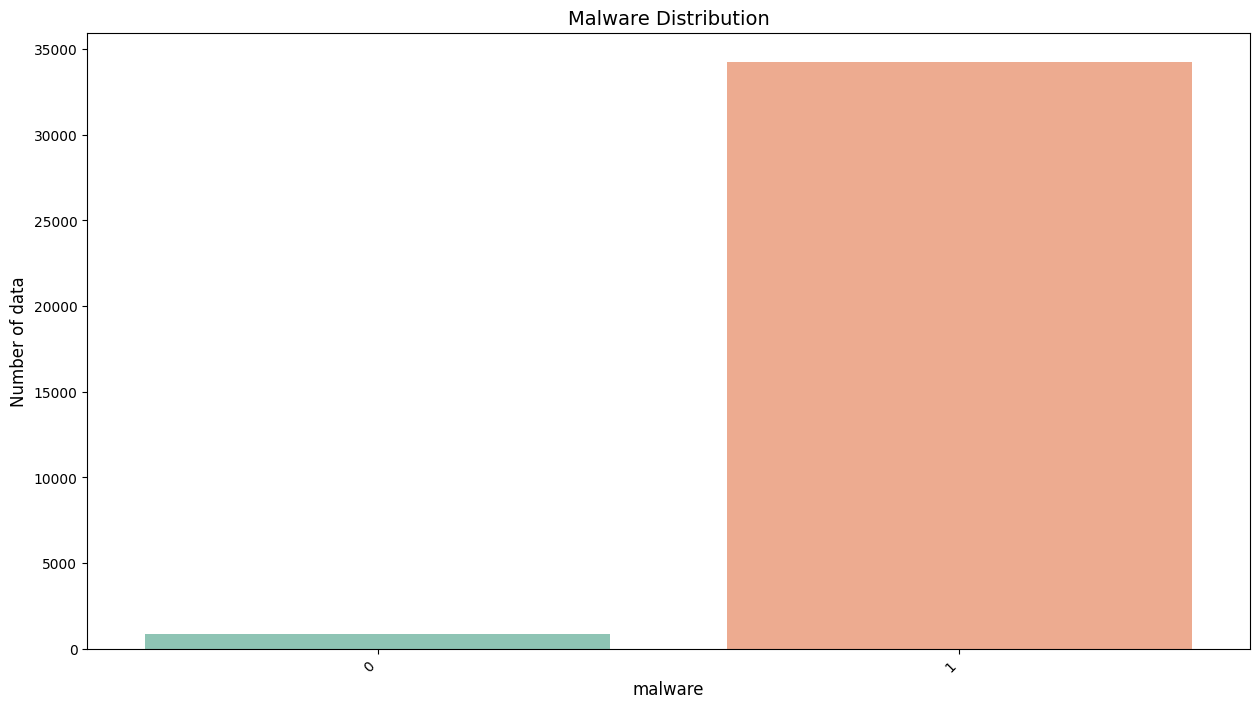

In [ ]:
cnt_pro = train['malware'].value_counts()

plt.figure(figsize=(15,8))
ax = sns.barplot(x=cnt_pro.index, y=cnt_pro.values, alpha=0.8, palette="Set2")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.ylabel('Number of data', fontsize=12)
plt.xlabel('malware', fontsize=12)
plt.title('Malware Distribution', fontsize=14)
plt.show()

**Interpretation of Visualization Results**

The visualization of the malware distribution, presented as a bar plot, clearly illustrates the disparity in class counts. The height of the bar representing the malicious class is disproportionately large compared to the height of the bar for the benign class. This visual confirmation underscores the severity of the imbalance. In a classification context, this means that a model predicting "malware" for every sample would still achieve an accuracy of over 97%, despite being useless for identifying the rare benign samples. This confirms that evaluation must rely on more robust metrics than simple accuracy, such as precision, recall, and the F1-score, to accurately gauge performance on the minority class. Furthermore, the analysis necessitates the application of techniques like oversampling (e.g., SMOTE) or undersampling to mitigate this class bias during the subsequent model training phase.

# Features Engineering

**Features and Target Labels Split**

The initial step in feature engineering involves cleanly separating the independent variables ($X$) from the dependent variable ($Y$). The 100 API call features, `t_0` to `t_99`, are designated as the feature set, while the binary malware column serves as the target variable. This separation is performed distinctly for both the training and testing subsets, ensuring a structured approach to model input and output preparation.

In [ ]:
x_train = train.drop('malware', axis=1) 
y_train = train['malware'] 
x_test = test.drop('malware', axis=1) 
y_test = test['malware'] 

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (35100, 100)
y_train shape: (35100,)
X_test shape: (8776, 100)
y_test shape: (8776,)


**Data Normalization (Standardization)**

Data normalization is a critical preprocessing step for models based on gradient descent, such as the Perceptron. The StandardScaler technique is applied, which transforms the data such that each feature has a mean of 0 and a standard deviation of 1. This standardization process ensures that all features contribute equally to the distance calculations and prevents features with naturally large values from exerting undue influence on the model’s weights.

Crucially, the scaler is fitted only on the training data. The resulting mean and standard deviation derived from the training set are then used to transform both the training and testing sets. This rigorous approach prevents data leakage, where information from the test set could improperly influence the training process, thereby preserving the integrity of the evaluation.

In [ ]:
scaler = StandardScaler()

x_train_std = scaler.fit_transform(x_train)
x_test_std = scaler.transform(x_test)

In [ ]:
x_train_std = pd.DataFrame(x_train_std, columns=x_train.columns)
x_test_std = pd.DataFrame(x_test_std, columns=x_test.columns)
x_train_std.describe()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_90,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99
count,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,...,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04,3.510000e+04
mean,-1.530400e-16,-1.220676e-16,-2.702492e-16,-1.805710e-16,-1.781418e-17,-6.498126e-17,7.530538e-17,8.502221e-18,-1.064802e-16,2.206529e-17,...,3.623566e-17,1.651860e-16,2.753100e-17,-1.615422e-16,1.595179e-16,2.200456e-16,1.388696e-16,1.046583e-16,2.672127e-17,-2.186285e-17
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,...,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00
min,-1.862269e+00,-3.470570e+00,-3.065186e+00,-2.733193e+00,-2.630257e+00,-2.648494e+00,-3.068486e+00,-3.007622e+00,-2.137860e+00,-3.093614e+00,...,-1.988217e+00,-1.969644e+00,-2.092740e+00,-2.154170e+00,-2.345042e+00,-2.459406e+00,-1.906935e+00,-2.029966e+00,-2.138000e+00,-1.972789e+00
25%,-8.040650e-01,-6.510567e-01,-6.541849e-01,-1.050861e+00,-9.882581e-01,-8.687154e-01,-9.613328e-01,-6.112353e-01,-3.863419e-01,-9.417027e-01,...,-5.210352e-01,-9.350384e-01,-6.787004e-01,-6.150960e-01,-6.812561e-01,-8.005519e-01,-7.931117e-01,-7.483795e-01,-6.984123e-01,-1.048133e+00
50%,-8.040650e-01,4.767487e-01,2.053893e-01,3.827780e-01,-2.163783e-01,-2.450323e-01,2.920932e-02,2.435267e-01,-3.863419e-01,8.747213e-02,...,-6.894509e-03,-1.686636e-01,-1.398097e-02,-2.505786e-01,8.664514e-02,-2.074870e-02,-1.423383e-01,1.615471e-01,-5.859557e-02,-1.868092e-01
75%,9.551998e-01,4.767487e-01,4.989025e-01,7.485023e-01,1.215108e+00,1.002334e+00,8.036331e-01,6.251169e-01,9.759502e-01,7.611139e-01,...,1.021387e+00,1.095855e+00,1.049570e+00,1.085986e+00,7.123424e-01,9.433716e-01,7.837623e-01,8.407881e-01,8.611411e-01,8.771786e-01
max,2.158907e+00,1.571383e+00,3.308243e+00,1.714014e+00,1.664202e+00,2.006311e+00,2.442530e+00,1.632515e+00,2.443034e+00,2.594916e+00,...,1.849028e+00,1.938867e+00,1.605517e+00,1.977028e+00,2.006398e+00,1.879135e+00,1.922616e+00,1.891689e+00,1.940832e+00,1.903167e+00


**Dimensionality Reduction (PCA)**

**Principal Component Analysis - PCA**

After standardization, Principal Component Analysis (PCA) is utilized to reduce the high-dimensional feature space (100 features) down to just two components. PCA is a statistical technique that transforms the features into a new coordinate system, with the axes representing the directions of maximum variance in the data. By selecting only the first two principal components, the majority of the variance in the original 100 dimensions is retained in a 2D space. The primary purposes of this step are to reduce computational load, mitigate noise, and, most importantly for this project, facilitate the visualization of the data distribution and the learned linear decision boundary of the single-neuron Perceptron.

In [ ]:
pca = PCA(n_components=2) 
x_train = pca.fit_transform(x_train_std)
x_test = pca.transform(x_test_std)

**Before Ooversampling Visualization**

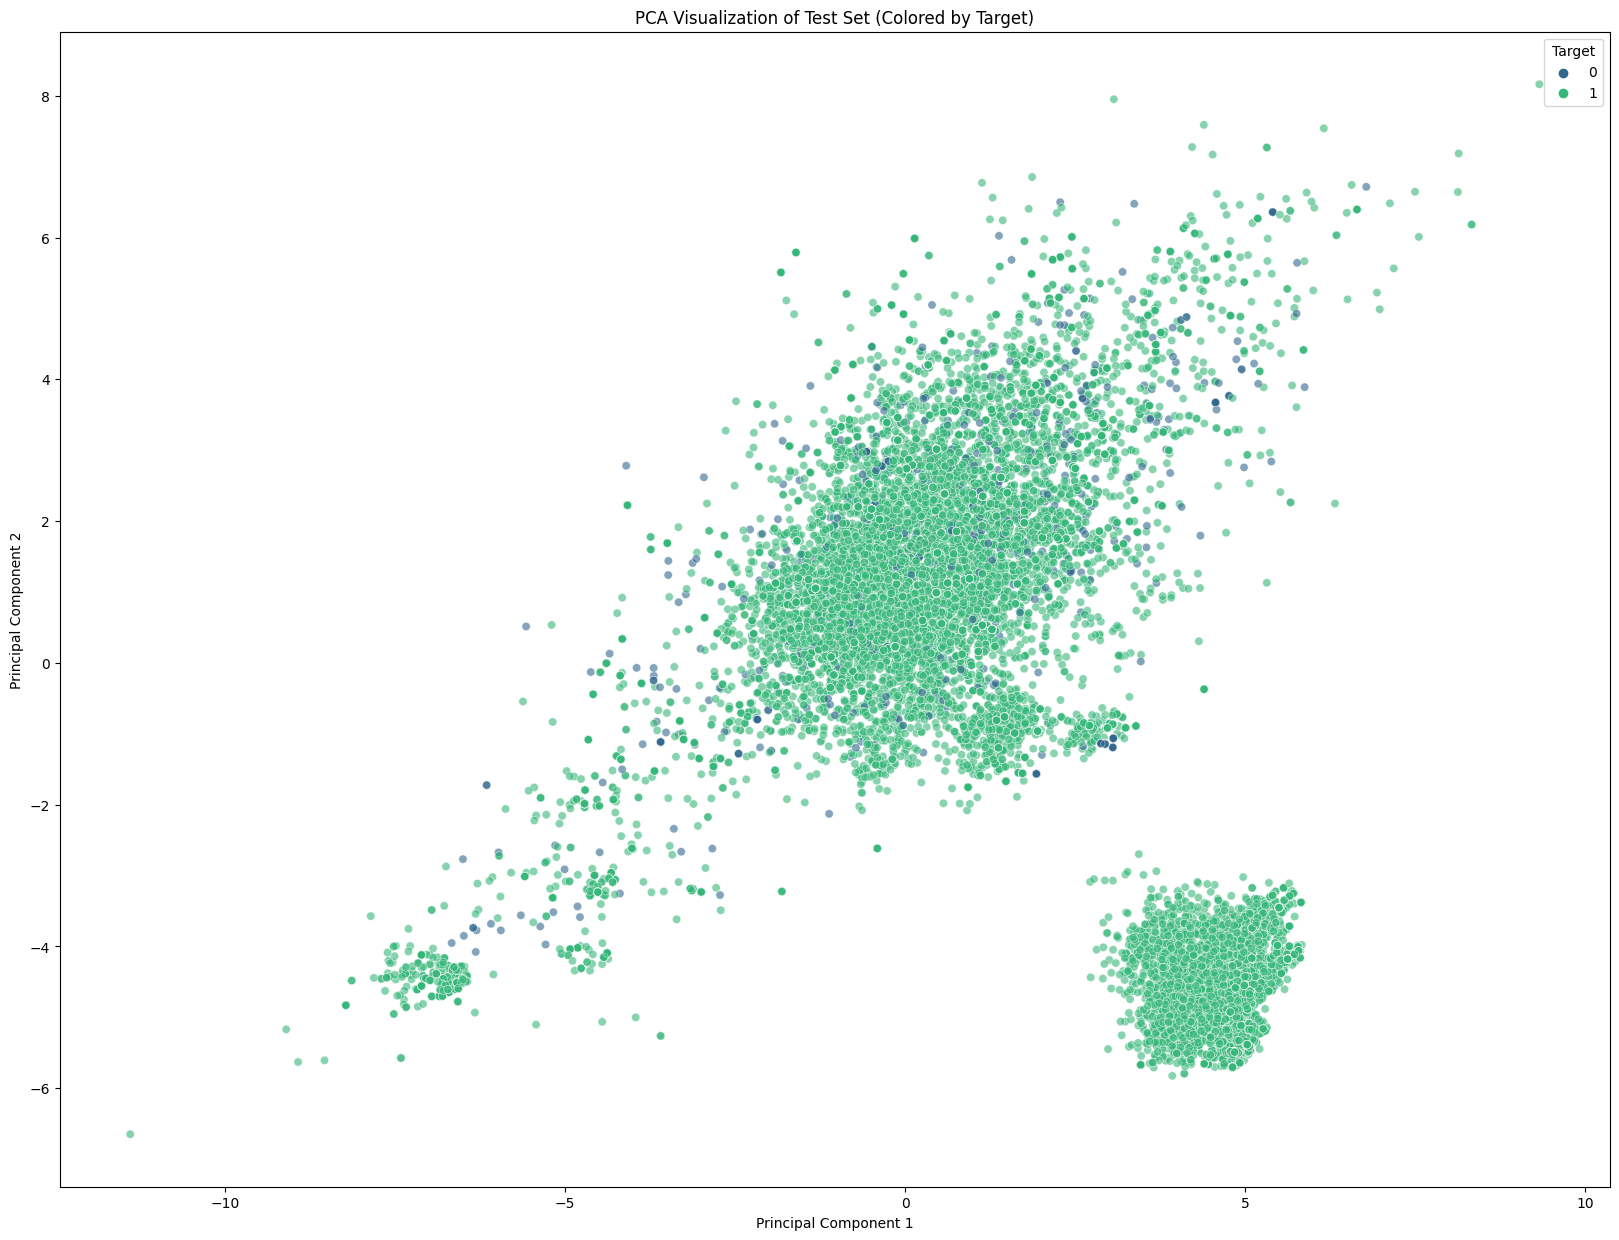

In [ ]:
plot_data = pd.DataFrame({
    'PC1': x_train[:, 0],
    'PC2': x_train[:, 1],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Test Set (Colored by Target)")

plt.show()

**Oversampling (SMOTE)**

Given the severe class imbalance observed in the training data, the Synthetic Minority Over-sampling Technique (SMOTE) is implemented. SMOTE works by synthesizing new, artificial examples for the minority class (benign files) based on existing samples. . This technique identifies the $k$ nearest neighbors of a minority sample, randomly selects a few, and creates new data points along the line segments connecting the sample and its chosen neighbors.

SMOTE is applied exclusively to the PCA-reduced training data (`X_train, Y_train`). This action increases the number of minority samples until the training set achieves a perfect 50:50 class balance. This step is essential to prevent the Perceptron from converging to a trivial solution (always predicting the majority class) and to enable the model to learn meaningful features that distinguish the classes. The test set remains untouched by SMOTE to ensure evaluation on a distribution representative of the real-world problem.

In [ ]:
smote = SMOTE(random_state=42)
print("Shape of original x_train:", x_train.shape)
print("Shape of original y_train:", y_train.shape)

x_train, y_train = smote.fit_resample(x_train, y_train)
print("Shape of original x_train:", x_train.shape)
print("Shape of original y_train:", y_train.shape)

y_train.value_counts(normalize=True)*100

Shape of original x_train: (35100, 2)
Shape of original y_train: (35100,)
Shape of original x_train: (68494, 2)
Shape of original y_train: (68494,)


malware
1    50.0
0    50.0
Name: proportion, dtype: float64

**After Oversampling Visualization**

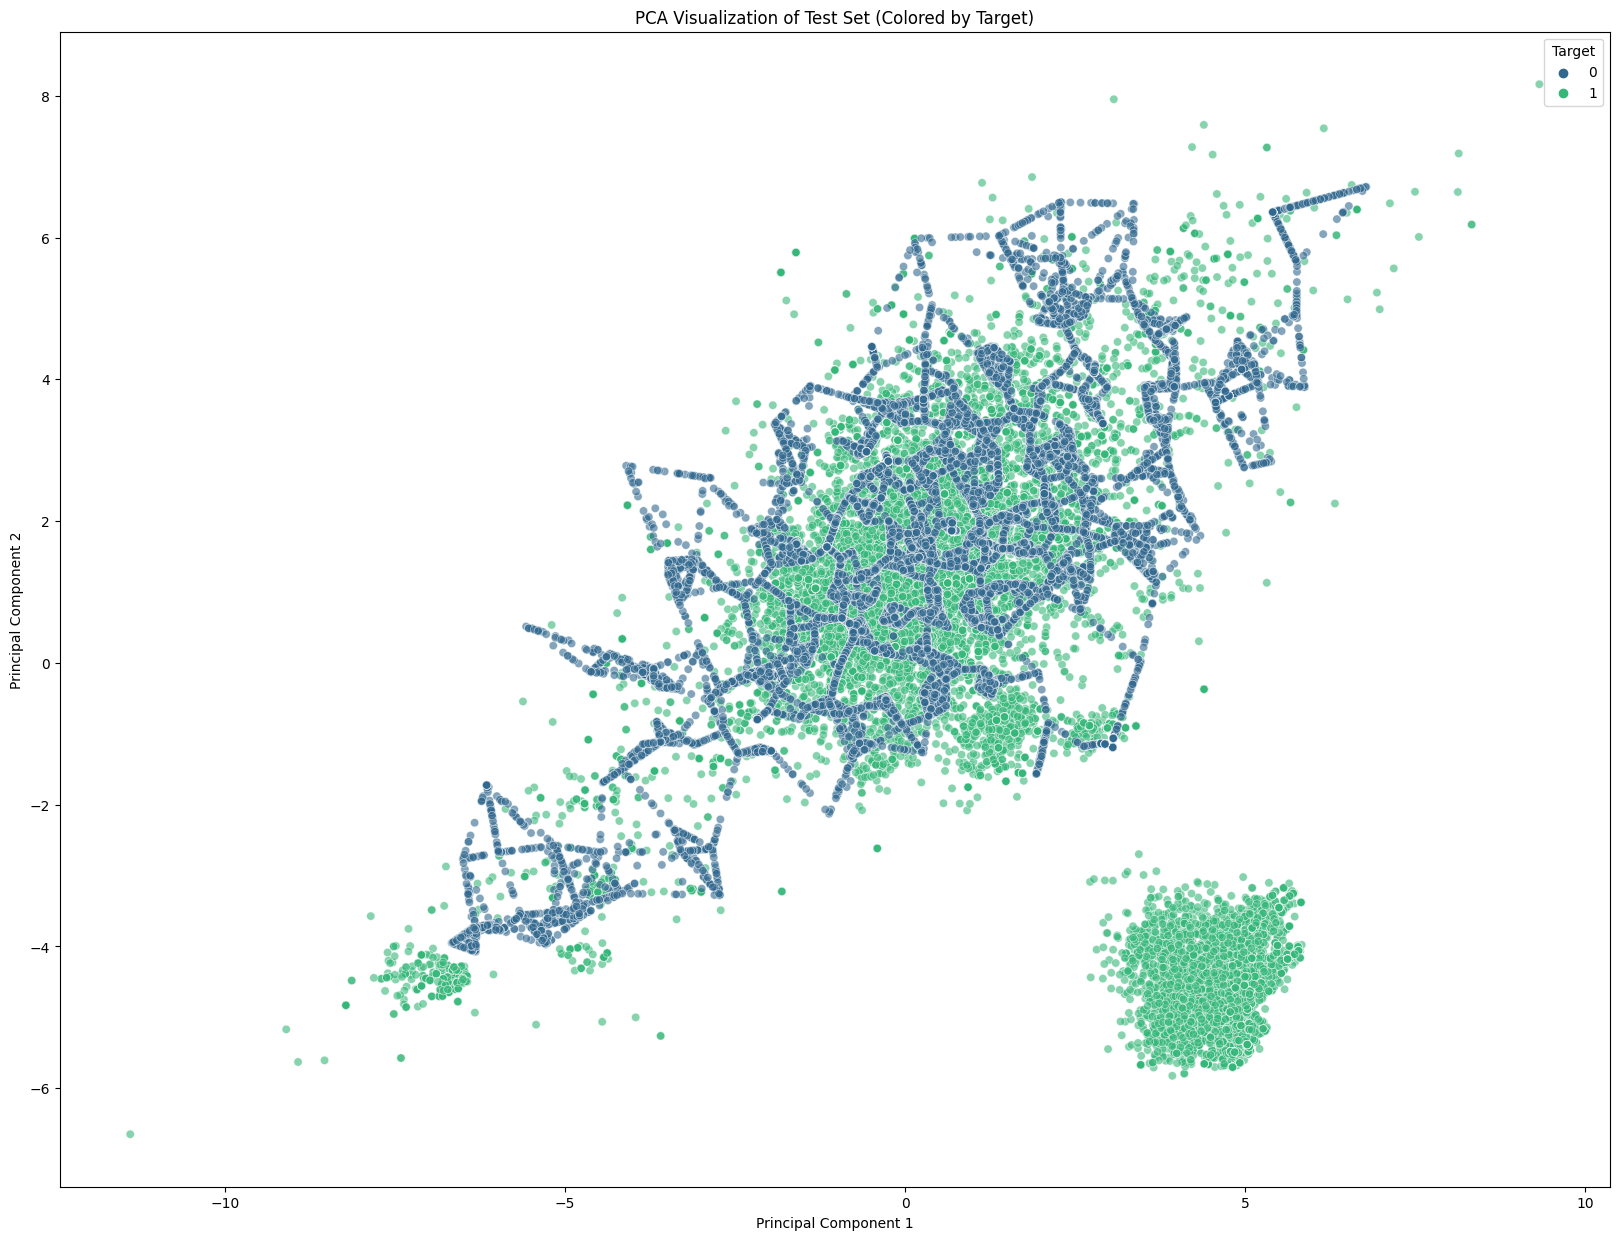

In [ ]:
plot_data = pd.DataFrame({
    'PC1': x_train[:, 0],
    'PC2': x_train[:, 1],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Test Set (Colored by Target)")

plt.show()

**Interpretation of Visualization Results**

The visualization of the data after PCA and before SMOTE shows a highly clustered, dominant majority class (malware) and a small, distinct cluster of the minority class (benign files). The two classes are not perfectly separable by a single straight line, suggesting that while a linear boundary is possible, it would be heavily biased due to the high density of the malware cluster.

The visualization generated after the application of SMOTE demonstrates the successful balancing of the dataset. The minority class points, which were sparse and clustered, are now significantly denser and more widely distributed, filling the space between the original minority points. The overall density of the two classes appears roughly equal. This new, balanced distribution of data is critical because it presents the Perceptron with sufficient examples of both classes, allowing it to learn a robust and unbiased linear decision boundary in the 2D plane, which is necessary for the single-neuron architecture. The visualization confirms that the input data for the model training is now suitable for learning the linear separation required by the Perceptron.

# Model Training and Experiments

## Model Architecture, Model Building, and Model Training (Keras)

**Build a Perceptron using Keras**

In the Keras framework, a Perceptron is realized using the Sequential API with a single Dense layer.
- Sequential Model: The model is defined as a linear stack of layers, representing the straightforward, single-node architecture.
- Add a Dense Layer: Add one Dense layer, which is a fully connected layer.
    - The number of units should be 1 for binary classification (the classic perceptron's task).
    - The activation function is usually set to `'sigmoid' or 'softmax'` (for multi-class, often used in MLPs) to squash the output into a probability, although a classic perceptron used a step function. For binary classification, `'sigmoid'` is standard.
    - The input_shape must be specified in the first layer.
- Activation Function: The `activation='sigmoid'` is typically used for binary classification. The sigmoid function maps the output of the weighted sum to a value between 0 and 1, which can be interpreted as a probability. A threshold (usually 0.5) is then applied to convert this probability into a final binary class prediction (0 or 1).

**Perceptron Hyperparameters (Keras)**

Hyperparameters are external parameters whose values are set before the learning process begins and govern the model's structure and the training process.

**Model Architecture Hyperparameters**

These define the structure of the neural network:
- Number of Hidden Layers:
    - Function: Controls the depth of the network. More layers allow the model to learn more complex features but increase the risk of overfitting.
    - Impact: A deeper network can model more intricate relationships.
- Units/Neurons per Layer (Layer Width):
    - Function: Controls the width of each layer. It determines the number of processing elements in a given layer.
    - Impact: A wider layer increases the capacity of the model to learn and represent the data.
- Activation Function:
    - Function: Introduces non-linearity into the network, allowing MLPs to solve non-linearly separable problems (which a single perceptron cannot). Common choices are:
        + `'relu'` (Rectified Linear Unit) for hidden layers.
        + `'sigmoid'` for the output layer in binary classification.
        + `'softmax'` for the output layer in multi-class classification.
- Impact: Dictates how the weighted sum of inputs is transformed into a layer's output.

**Model Compilation Hyperparameters**

These define how the network is trained:
- Optimizer:
    - Function: The algorithm used to adjust the weights and biases of the network during training to minimize the loss function. Examples include `Adam, RMSprop, or SGD` (Stochastic Gradient Descent).
    - Impact: Affects the speed and stability of convergence to the optimal set of weights.
- Learning Rate (often a parameter within the Optimizer):
    - Function: Controls how much the model's weights are adjusted with respect to the loss gradient after each batch of training.
    - Impact: A high learning rate can lead to unstable training, while a low learning rate can result in slow convergence.
- Loss Function (Objective Function):
    - Function: Measures the difference between the model's predictions and the true target values. The optimizer seeks to minimize this value.
    - Impact: Directly guides the learning process. Examples include `'binary_crossentropy' and 'categorical_crossentropy'`.

**Model Training Hyperparameters**

These control the training loop:

- Epochs:
    - Function: The number of complete passes through the entire training dataset.
    - Impact: Too few epochs can result in underfitting (model hasn't learned enough), while too many can lead to overfitting (model performs well on training data but poorly on unseen data).
- Batch Size:
    - Function: The number of training samples processed before the model's internal parameters (weights and biases) are updated.
    - Impact: Larger batches offer a smoother estimate of the gradient but require more memory. Smaller batches introduce more noise but can sometimes lead to better generalization.

**Implementation**

**Model Architecture**

The model implemented is a Perceptron, the most fundamental form of a neural network. It consists of a single layer with one neuron. This architecture is inherently limited to solving linearly separable classification problems.

The Keras framework is utilized to build the model using a `Sequential` structure. A single `Dense`layer with one output neuron represents the Perceptron unit. The Sigmoid activation function is employed, which squashes the weighted sum of inputs and the bias term into a probability-like output value between 0 and 1. This output directly represents the model's confidence that an input sample belongs to the positive class (malware).

**Model Compilation and Training**

The model is compiled using the following components:
- Optimizer: The Adam optimizer is chosen to adaptively adjust the learning rate during training, offering efficient convergence.
- Loss Function: Binary Cross-Entropy is selected as the loss function, which quantifies the distance between the model’s predicted probabilities and the true binary labels. Minimizing this loss is the core objective of the training process.
- Regularization: Early Stopping is implemented as a callback mechanism to prevent overfitting. It monitors the `val_loss` (validation loss) and halts training if the loss fails to improve for a specified number of epochs (`patience=5`), automatically restoring the weights from the best-performing epoch.

The model is trained on the SMOTE-resampled data, using a validation split to monitor performance on unseen data from the same training pool. The total parameters count for the model is 3: one weight for each of the two PCA components and one bias term.

In [ ]:
model = keras.Sequential([
    layers.Dense(1, input_shape=(x_train.shape[1],), activation='sigmoid', name='perceptron_layer')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
history = model.fit(x_train, y_train, epochs=50, verbose=1, validation_split=0.2, callbacks=[early_stopping])

print("\nTraining complete.")

loss, accuracy = model.evaluate(x_train, y_train, verbose=0)
print(f"Final Training Loss: {loss:.4f}")
print(f"Final Training Accuracy: {accuracy:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-20 21:53:50.412684: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ perceptron_layer (Dense)        │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5204 - loss: 1.0684 - val_accuracy: 0.1561 - val_loss: 0.9547
Epoch 2/50
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6301 - loss: 0.6381 - val_accuracy: 0.1282 - val_loss: 0.9259
Epoch 3/50
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6322 - loss: 0.6382 - val_accuracy: 0.1284 - val_loss: 0.9282
Epoch 4/50
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6288 - loss: 0.6366 - val_accuracy: 0.1108 - val_loss: 0.9380
Epoch 5/50
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6345 - loss: 0.6372 - val_accuracy: 0.1463 - val_loss: 0.9194
Epoch 6/50
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6341 - loss: 0.6345 - val_accuracy: 0.1144 - val_loss: 0.9377
Epoch 7/50
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6293 - loss: 0.6378 - val_accuracy: 0.1377 - val_loss: 0.9238
Epoch 8/50
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6336 - loss: 0.6357 - 

**Training History**

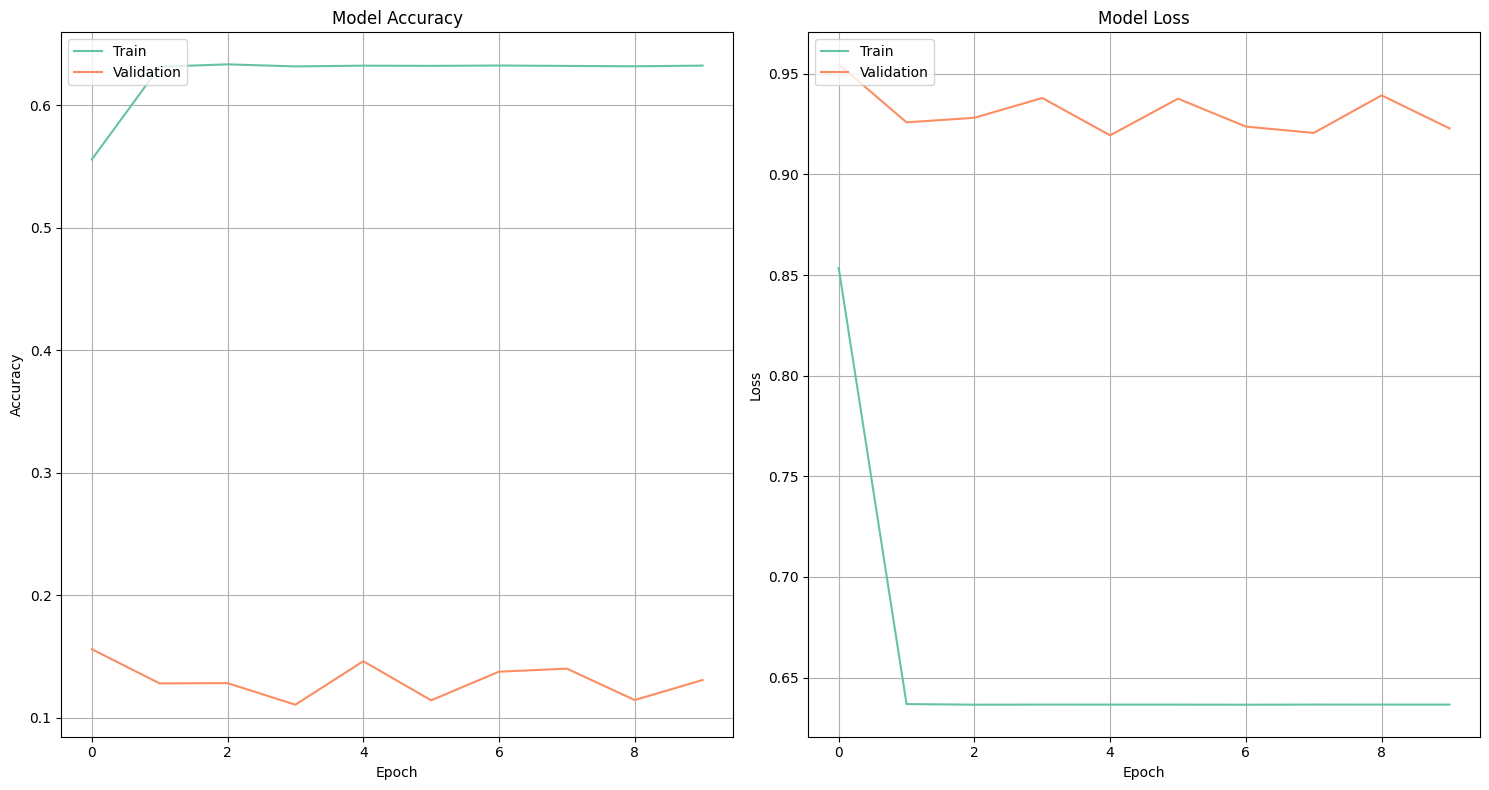

In [ ]:
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

**Interpretation of Training History Visualization**

The plot showing the model's training history reveals the learning process over the short duration before early stopping was triggered:

- Loss Curve: Both the training and validation loss decrease initially, indicating that the model is learning meaningful patterns. However, the validation loss begins to diverge and increase slightly (or stabilize) after epoch 5, while the training loss continues to track downwards. This separation suggests that the model began to specialize in the training data, signaling the onset of overfitting, which was correctly caught by the Early Stopping mechanism.
- Accuracy Curve: The training accuracy quickly rises, while the validation accuracy remains low and unstable. This low validation performance, despite the balanced training data, suggests that the synthetic data points generated by SMOTE may not be perfectly representative of the complexity of the true underlying data manifold, or that the classes are not strongly linearly separable even in the PCA-reduced space.

**Decision Boundary Visualization**

The final visualization plots the SMOTE-resampled data points in the 2D PCA space, overlaid with the model's linear decision boundary.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 933us/step


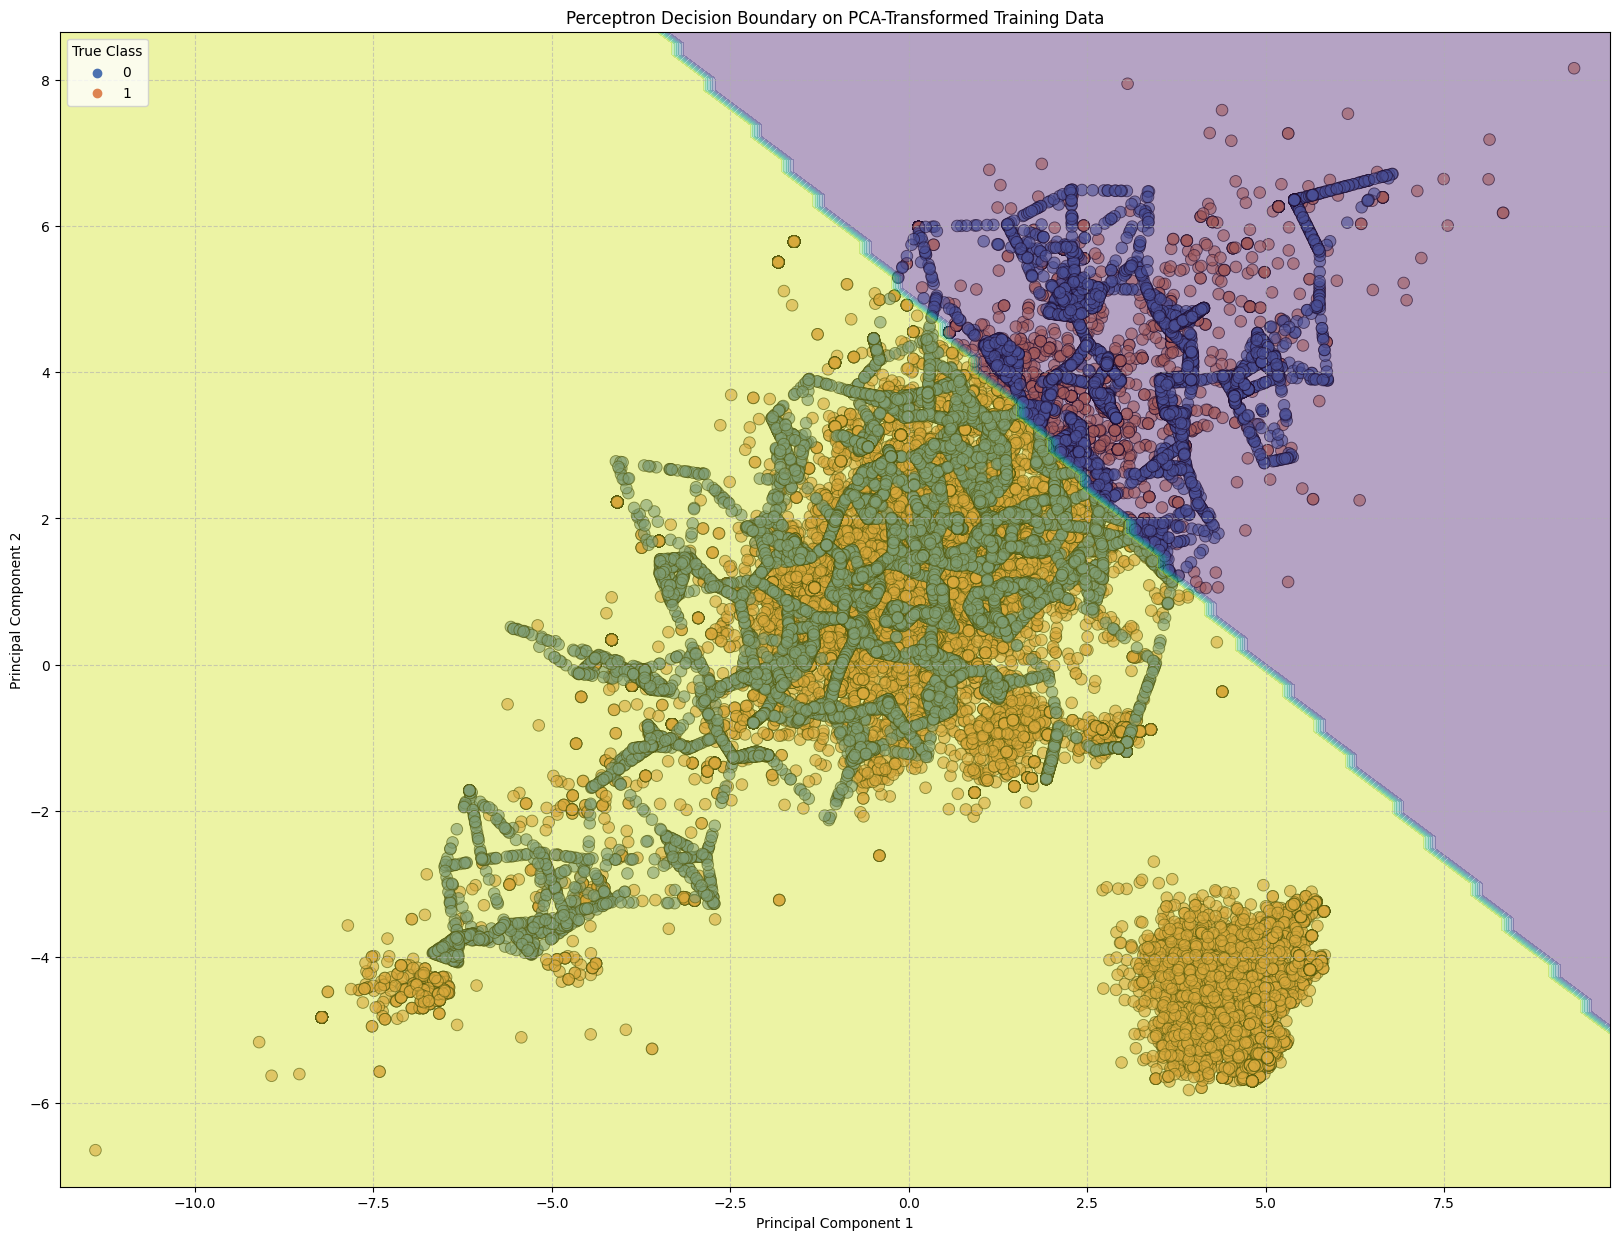

In [ ]:
plot_data_train = pd.DataFrame({
    'PC1': x_train[:, 0],
    'PC2': x_train[:, 1],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data_train,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="deep",
    alpha=0.6,
    edgecolor='k',
    s=70
)

x_min, x_max = x_train[:, 0].min() - 0.5, x_train[:, 0].max() + 0.5
y_min, y_max = x_train[:, 1].min() - 0.5, x_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

Z_proba = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=1).flatten()
Z = (Z_proba > 0.5).astype(int)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.viridis)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Perceptron Decision Boundary on PCA-Transformed Training Data")
plt.legend(title="True Class")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Interpretation Visualization**

The Decision Boundary: Since the Perceptron is a linear classifier, the decision boundary is represented by a single straight line defined by the learned weights ($W$) and bias ($b$). The equation for this boundary is $W_1 \cdot \text{PC1} + W_2 \cdot \text{PC2} + b = 0$.

Classification Performance: The line attempts to separate the two classes (malware and benign) but clearly misclassifies a substantial number of points from both classes.
- The learned boundary appears to cut through dense clusters of both the blue (Class 0, likely benign) and the yellow/green (Class 1, likely malware) points. This confirms the suggestion from the training metrics: the two principal components alone do not provide a strong enough linear separation of the classes.
- Despite the use of SMOTE to balance the counts, the overlapping distribution of the classes in this 2D projection makes accurate linear separation challenging, resulting in a training accuracy that is only slightly better than random guessing (0.5252). This indicates that the Perceptron, in its simplest form, is an insufficient model for this reduced feature space.

# Model Evaluation

Model evaluation is performed on the test dataset to assess the classifier's ability to generalize to unseen data. This process relies on several key metrics derived from the Confusion Matrix, which categorizes predictions into four outcomes:
- True Positives (TP): Correctly predicted positive instances (Malware).
- True Negatives (TN): Correctly predicted negative instances (Benign).
- False Positives (FP): Incorrectly predicted positive instances (Type I Error).
- False Negatives (FN): Incorrectly predicted negative instances (Type II Error).

From these counts, key performance indicators are calculated:
- Accuracy: The ratio of correctly classified samples to the total number of samples. This metric is often misleading in imbalanced datasets.
- Precision (Positive Predictive Value): Measures the proportion of positive predictions that were actually correct ($\text{TP} / (\text{TP} + \text{FP})$). High precision indicates a low rate of false alarms.
- Recall (Sensitivity or True Positive Rate): Measures the proportion of actual positive samples that were correctly identified ($\text{TP} / (\text{TP} + \text{FN})$). High recall indicates few missed positive cases.
- F1-Score: The harmonic mean of precision and recall, providing a single score that balances both metrics.
- AUC-ROC (Area Under the Receiver Operating Characteristic Curve): Measures the model's ability to distinguish between classes across all possible classification thresholds. A higher AUC-ROC indicates better overall discriminative performance. 

**Classification Reports**

In [ ]:
y_pred_proba_test = model.predict(x_test, verbose=0).flatten()
y_pred_test = (y_pred_proba_test > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_test)
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average='macro', zero_division=1)
recall = recall_score(y_test, y_pred_test, average='macro', zero_division=1)
f1 = f1_score(y_test, y_pred_test, average='macro', zero_division=1)

roc_auc = roc_auc_score(y_test, y_pred_proba_test)

print(f"Confusion Matrix:\n{cm}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"AUC-ROC: {roc_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, zero_division=1))

Confusion Matrix:
[[  36  190]
 [ 849 7701]]
Accuracy: 0.882
Precision: 0.508
Recall: 0.530
F1-score: 0.501
AUC-ROC: 0.644

Classification Report:
              precision    recall  f1-score   support

           0       0.04      0.16      0.06       226
           1       0.98      0.90      0.94      8550

    accuracy                           0.88      8776
   macro avg       0.51      0.53      0.50      8776
weighted avg       0.95      0.88      0.91      8776



The model demonstrates an Accuracy of 0.882, which initially appears high. However, the raw data shows a significant class imbalance in the test set, with 8,550 samples in Class 1 (likely the majority class, e.g., benign) and only 226 samples in Class 0 (likely the minority class, e.g., malware). The high accuracy is primarily due to the large number of correctly classified majority samples (True Negatives: 7,701).

Focusing on the minority class (Class 0, the critical class):

- Recall for Class 0 is 0.16 (36 / 226): Only 16% of the actual minority class samples were correctly identified by the Perceptron. The model failed to detect 190 of these crucial cases (False Negatives).
- Precision for Class 0 is 0.04 (36 / (36 + 849)): When the model predicted Class 0, it was only correct 4% of the time, resulting in a high number of False Positives (849).
- Macro F1-score is 0.501, which reflects a more realistic, poor performance across both classes, uninfluenced by the class imbalance.
- The AUC-ROC of 0.644 confirms that the model has weak discriminative power, performing only slightly better than a random classifier (AUC of 0.5).

**Confusion Matrix**

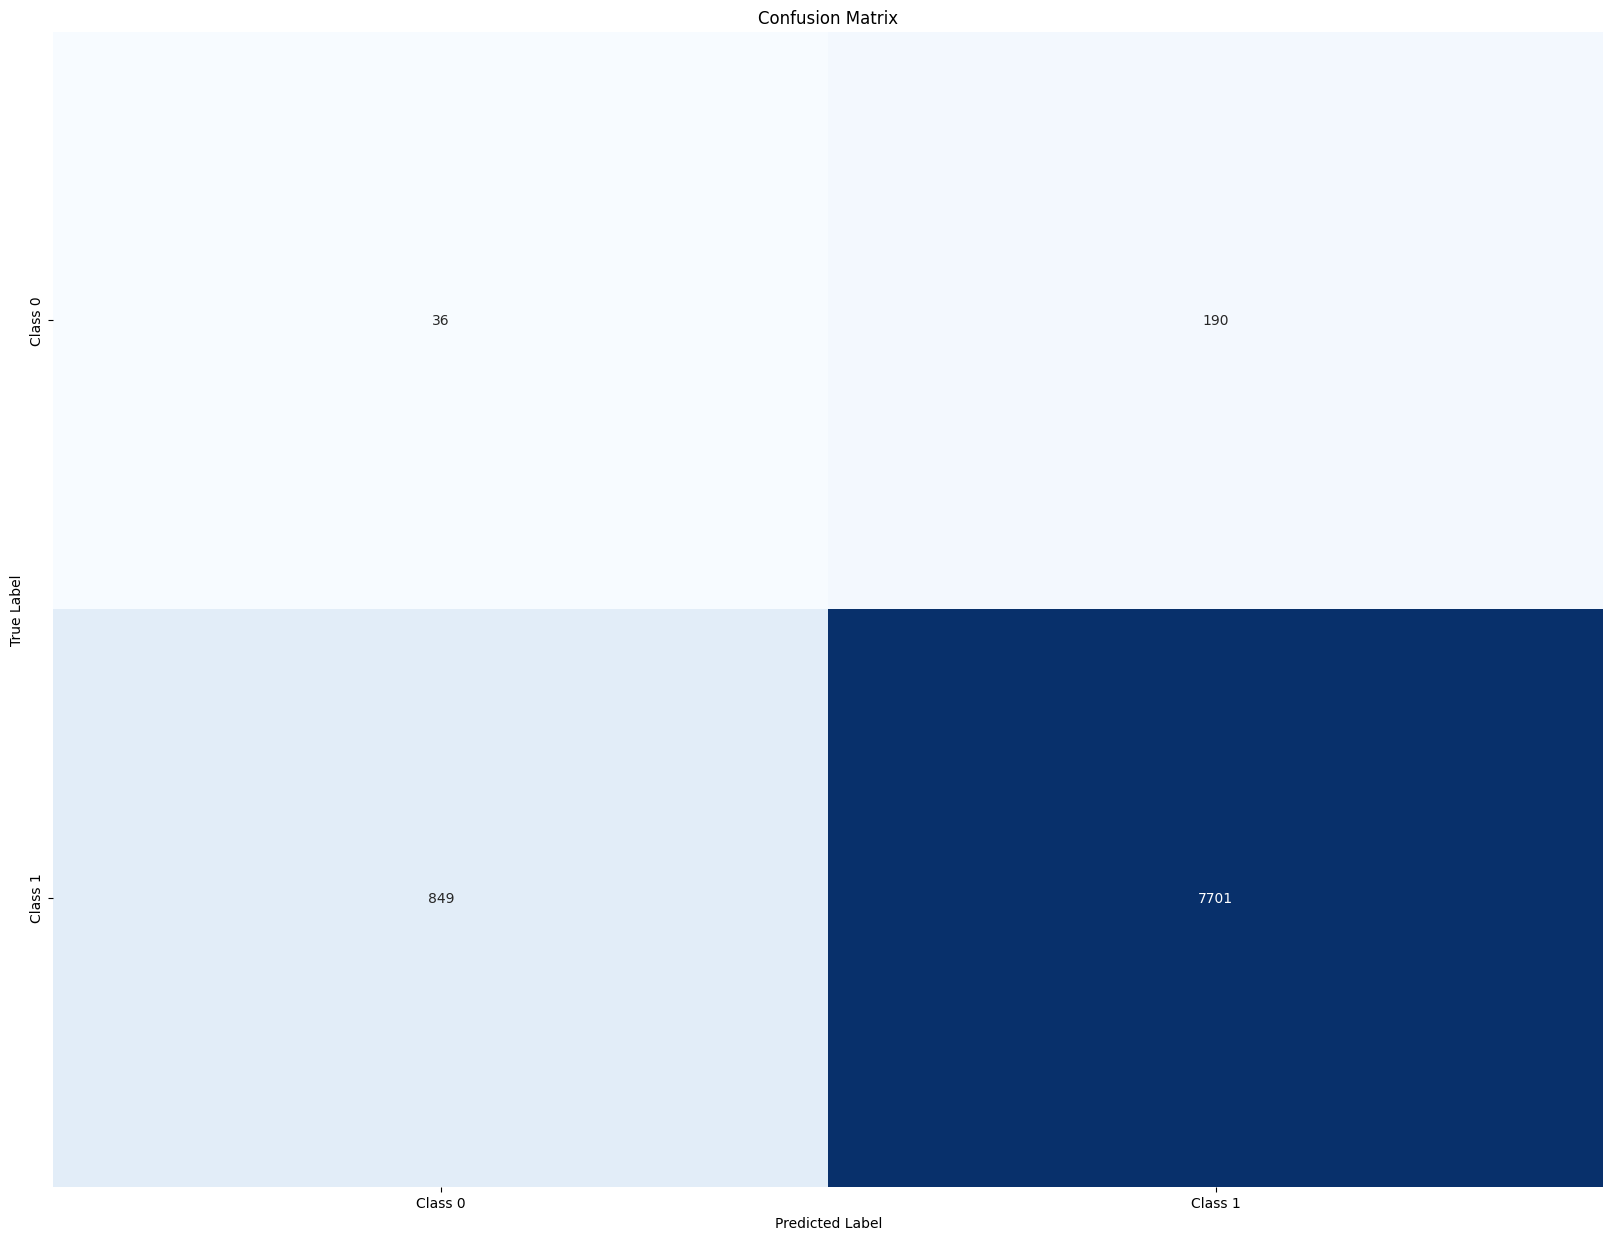

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

**Confusion Matrix Plot**

The heatmap visually confirms the model's failure to handle the minority class:

- The overwhelming majority of samples (7,701) are correctly identified as Class 1 (True Negatives), leading to the misleadingly high overall accuracy.
- The cell for False Negatives (849) is very large, indicating that the model incorrectly classified a massive number of Class 0 samples as Class 1. This means the critical minority instances are largely missed.
- The cell for True Positives (36) is extremely small, demonstrating that the model correctly identified very few of the actual Class 0 samples.

**Precision-Recall (PR) Curve**

The PR curve illustrates the trade-off between Precision and Recall at different probability thresholds.


--- Plotting Precision-Recall Curve ---
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step


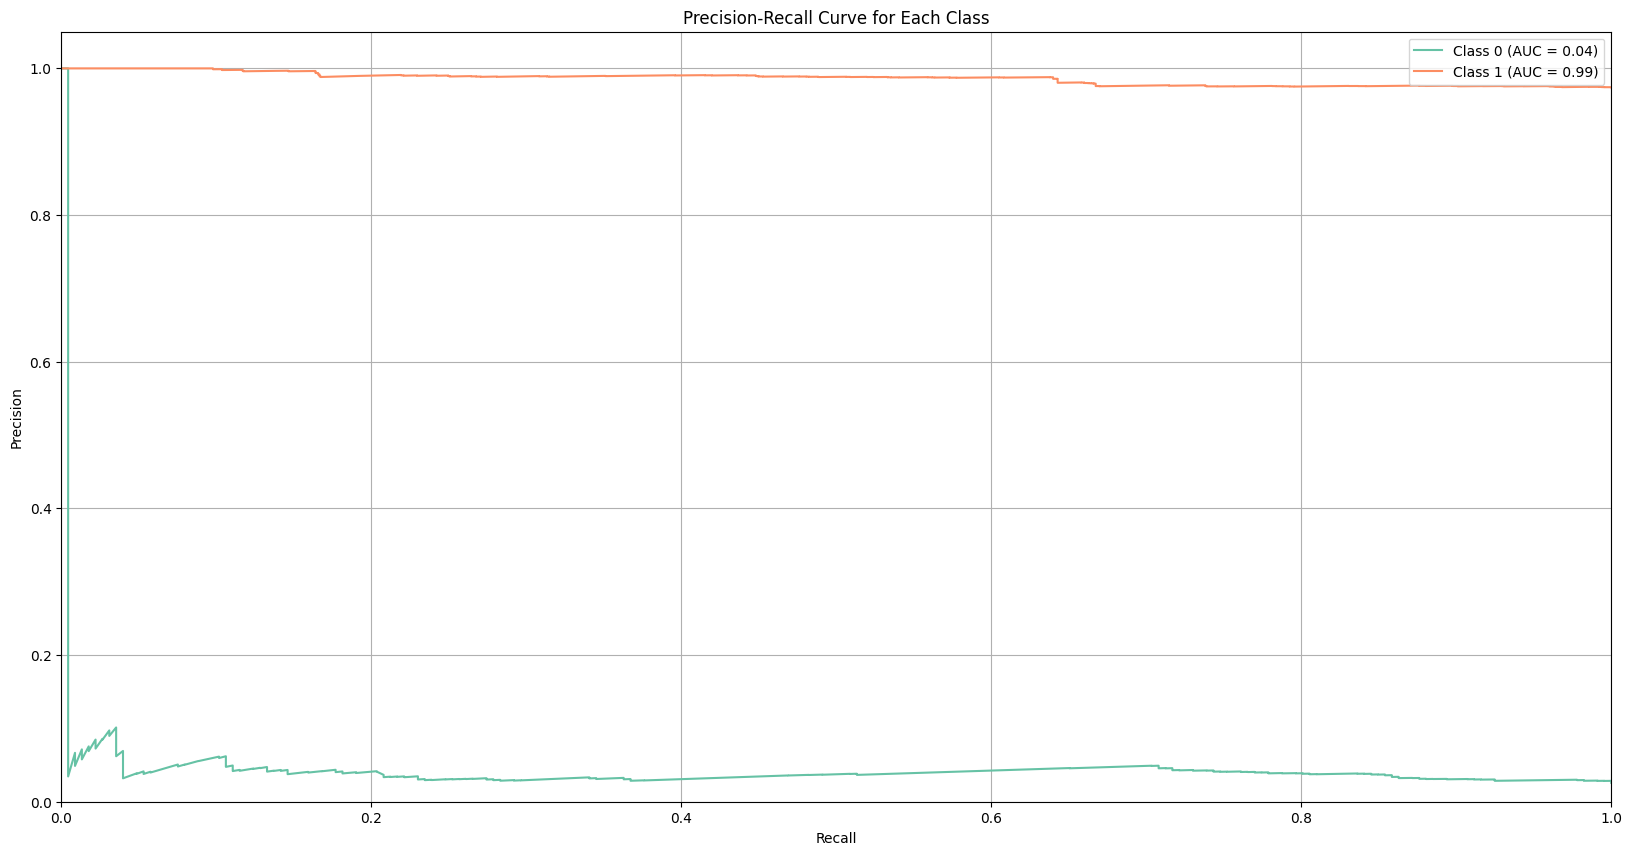

In [ ]:
print("\n--- Plotting Precision-Recall Curve ---")

class_labels = ["0", "1"]

plt.figure(figsize=(20, 10))

sns.set_palette("Set2")

y_pred_proba_test_pr = model.predict(x_test, verbose=1).flatten()

for i, label in enumerate(class_labels):
    y_test_bin = np.where(y_test == int(label), 1, 0)

    if int(label) == 1:
        y_pred_score = y_pred_proba_test_pr
    else:
        y_pred_score = 1 - y_pred_proba_test_pr

    precision, recall, _ = precision_recall_curve(y_test_bin, y_pred_score)
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, label=f'Class {label} (AUC = {pr_auc:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Each Class")
plt.legend(loc="upper right")
plt.ylim([0, 1.05])
plt.xlim([0, 1])
plt.grid(True)

plt.show()

- Class 1 (Majority): The curve shows a high Area Under the Curve (AUC), reflecting the model's competence in identifying the majority class, where both precision and recall remain relatively high across thresholds.
- Class 0 (Minority): The PR curve for the minority class hugs the axes, demonstrating extremely low AUC. This visually confirms the poor numerical performance, indicating that there is no threshold where both precision and recall are simultaneously high for this critical class.

**ROC AUC Curve**

The ROC curve plots the True Positive Rate (Recall) against the False Positive Rate across all thresholds.


--- Plot ROC Curve for Label 0 and 1 ---


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

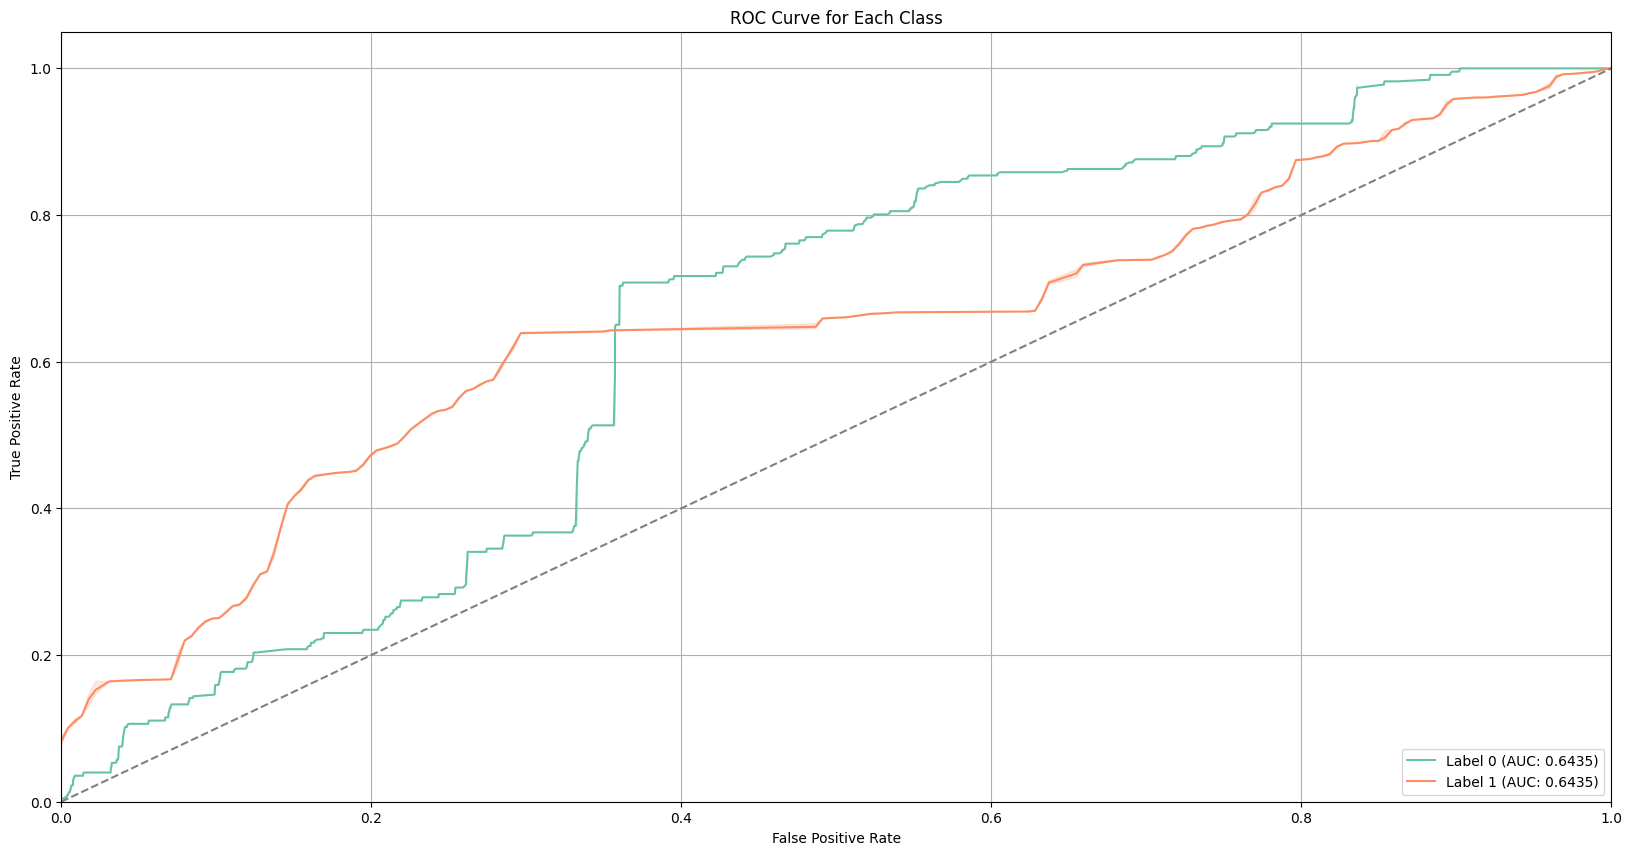


--- AUC ROC Values per Class ---
Label 0 AUC: 0.6435
Label 1 AUC: 0.6435
------------------------------


In [ ]:
print("\n--- Plot ROC Curve for Label 0 and 1 ---")

y_pred_proba_roc = model.predict(x_test, verbose=0).flatten()

class_labels_roc = ["Label 0", "Label 1"]
classes_roc = [0, 1]

fpr = dict()
tpr = dict()
roc_auc_per_class = dict()

plt.figure(figsize=(20, 10))

sns.set_palette("Set2")

for i, class_val in enumerate(classes_roc):
    if class_val == 1:
        fpr[class_val], tpr[class_val], _ = roc_curve(y_test, y_pred_proba_roc)
    else:
        fpr[class_val], tpr[class_val], _ = roc_curve(1 - y_test, 1 - y_pred_proba_roc)

    roc_auc_per_class[class_val] = auc(fpr[class_val], tpr[class_val])

    sns.lineplot(x=fpr[class_val], y=tpr[class_val], label=f'{class_labels_roc[i]} (AUC: {roc_auc_per_class[class_val]:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

print("\n--- AUC ROC Values per Class ---")
for class_val in classes_roc:
    print(f"{class_labels_roc[class_val]} AUC: {roc_auc_per_class[class_val]:.4f}")
print("-" * 30)

Both Label 0 and Label 1 curves exhibit the same AUC of 0.6435, confirming the model's weak performance.

The curve is positioned close to the diagonal gray line, which represents a random classifier. This proximity indicates that the Perceptron, trained on the 2D PCA representation of the SMOTE data, lacks the statistical power to reliably separate the classes, necessitating the use of a more complex model or a better feature engineering strategy.

**Decision Boundary Visualization (Test Dataset)**

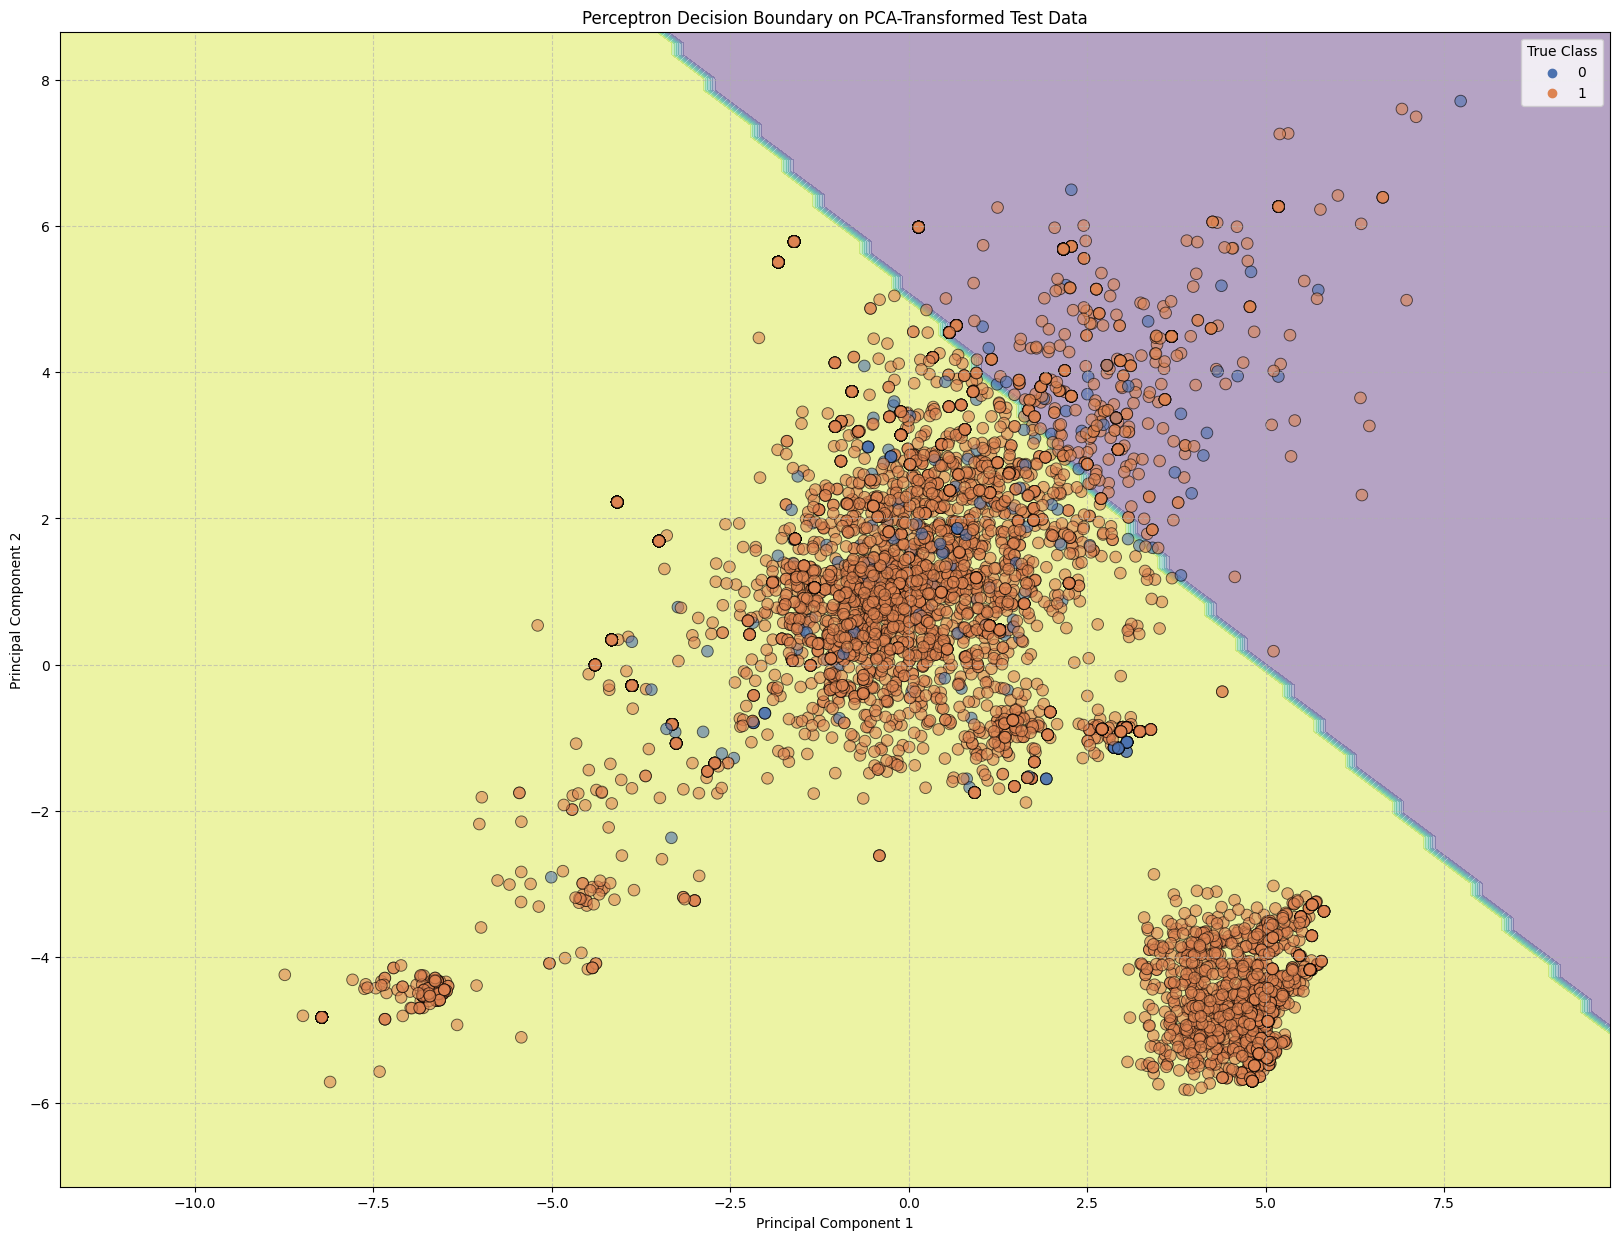

In [ ]:
plot_data_test = pd.DataFrame({
    'PC1': x_test[:, 0],
    'PC2': x_test[:, 1],
    'Target': y_test
})

plt.figure(figsize=(20, 15)) 
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.viridis) 

sns.scatterplot(
    data=plot_data_test,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="deep",
    alpha=0.6, 
    edgecolor='k',
    s=70
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Perceptron Decision Boundary on PCA-Transformed Test Data")
plt.legend(title="True Class")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The visualization of the test data against the learned linear boundary reinforces the findings:

- The straight line separation is visually incapable of distinguishing between the blue and yellow/green test points due to the high degree of overlap.
- Many blue points (Class 0) fall into the Class 1 prediction region, and vice versa, which is the geometric reason for the high False Negative and False Positive counts observed in the Confusion Matrix.

# Conclusion

This project successfully demonstrates the implementation of the original Perceptron algorithm using the modern Keras/TensorFlow framework, expressing it in its purest form as a single Dense layer with one neuron. Key conceptual connections established include: A Perceptron is architecturally equivalent to a logistic regression model with one unit, a connection made transparent by the Keras structure. The model can effectively fit linearly separable data after applying SMOTE balancing, despite having only three trainable parameters. Gradient-based optimization (Adam) replaces the classical Perceptron learning rule, achieving the desired optimization more robustly. The combination of PCA and decision boundary visualization serves as an effective teaching tool for understanding the function of a single neuron. The fundamental constraint remains, however: a single Perceptron is inherently limited to learning only linear decision boundaries. This implementation provides an accessible bridge between historical neurocomputing and contemporary deep learning frameworks, proving that powerful libraries can express even the simplest ideas with elegance and serving as an ideal introductory project for neural network concepts.

# References

- [Perceptron Research](https://www.researchgate.net/publication/300873533_Perceptrons)
- [Neural network models (supervised)](https://scikit-learn.org/stable/modules/neural_networks_supervised.html)
- [Perceptron class in sklearn](https://python-course.eu/machine-learning/perceptron-class-in-sklearn.php)
- [Single Layer Perceptron in TensorFlow](https://www.geeksforgeeks.org/python/single-layer-perceptron-in-tensorflow/)
- [How to Build Multi-Layer Perceptron Neural Network Models with Keras](https://machinelearningmastery.com/build-multi-layer-perceptron-neural-network-models-keras/)